In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')


DATA_PATH = r"C:/Files/GLAN_DATA/first_wave/individual_level/integrated_dataset.csv"

col_Y = 'who_5'                 #
col_T_Green = 'proportion_greenery' # proportion_greenery,greenery_visibility,  patch_density
col_T_Noise = 'LAeq_overall'        # LAeq_overall, LAeq_night, LAeq_evening, CV_overall,
col_M1 = 'sleep_duration'       #
col_M2 = 'MVPA_10min'           # 

cols_W = [
    "age", "gender", "education_level", "family_income",
    "PM2_5","temperature", "humidity"
]


df_raw = pd.read_csv(DATA_PATH)



all_cols = [col_Y, col_T_Green, col_T_Noise, col_M1, col_M2] + cols_W
df = df_raw[all_cols].copy()


scaler = StandardScaler()
df[all_cols] = scaler.fit_transform(df[all_cols])
                                                                                                                                                                        
print(f" {len(df)}  {len(all_cols)} ")

 658  12 


In [8]:
import torch
import pytorch_lightning as pl
import os
import numpy as np
import pandas as pd
from causica.datasets.variable_types import VariableTypeEnum
from causica.datasets.causica_dataset_format import Variable
from causica.distributions import ContinuousNoiseDist
from causica.lightning.data_modules.basic_data_module import BasicDECIDataModule
from causica.lightning.modules.deci_module import DECIModule
import random
from causica.training.auglag import AugLagLRConfig
print("=" * 70)
print(" DECI train")
print("=" * 70)
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)          # 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

actual_epochs = 120   # 120
# Lightning seed
pl.seed_everything(SEED, workers=True)
# ============================================================
# ============================================================================
# ============================================================================

variables = [Variable(group_name=c, name=c, type=VariableTypeEnum.CONTINUOUS) for c in df.columns]

num_nodes = len(df.columns)
features = df.columns.tolist()
constraints = np.full((num_nodes, num_nodes), np.nan, dtype=np.float32)

idx_Y = [features.index(col_Y)]
idx_M = [features.index(col_M1), features.index(col_M2)]
idx_T = [features.index(col_T_Green), features.index(col_T_Noise)]
idx_W = [features.index(c) for c in cols_W]

for i in idx_M + idx_T + idx_Y:
    for j in idx_W: constraints[i, j] = 0.0
for i in idx_M + idx_Y:
    for j in idx_T: constraints[i, j] = 0.0
for i in idx_Y:
    for j in idx_M: constraints[i, j] = 0.0

# idx_T_Green = features.index(col_T_Green)
# idx_T_Noise = features.index(col_T_Noise)
# constraints[idx_T_Noise, idx_T_Green] = 0.0
# constraints[idx_T_Green, idx_T_Noise] = 0.0
np.fill_diagonal(constraints, 0.0)
np.save("structural_constraints.npy", constraints)
# ============================================================================
class DECIConvergenceCallback(pl.Callback):
    """
    - dagness (DAG) →  0
    - num_edges → stable
    - batch_log_prob → stable
    
     dagness < le-3 log_prob  patience  epoch 
    """
    def __init__(self, patience=5, dagness_threshold=1e-4, min_epochs=50):
        super().__init__()
        self.patience = patience
        self.dagness_threshold = dagness_threshold
        self.min_epochs = min_epochs
        self.best_log_prob = -float('inf')
        self.wait = 0
        self.history = []
        self.val_log_probs = []
    def on_train_epoch_end(self, trainer, pl_module):
        #  trainer  logged metrics
        metrics = trainer.callback_metrics
        
        log_prob = metrics.get('batch_log_prob', None)
        constraint = metrics.get('constraint', None)
        num_edges = metrics.get('num_edges', None)
        epoch = trainer.current_epoch
        
        record = {'epoch': epoch}
        if log_prob is not None:
            record['log_prob'] = log_prob.item()
        if constraint is not None:
            record['dagness'] = constraint.item()
        if num_edges is not None:
            record['num_edges'] = num_edges.item()
        self.history.append(record)
        
        # 20  epoch print 
        if epoch % 20 == 0:
            lp = f"{record.get('log_prob', 0):.4f}"
            dg = f"{record.get('dagness', 0):.6f}"
            ne = f"{record.get('num_edges', 0):.0f}"
            print(f"    Epoch {epoch:>3d}: log_prob={lp}, dagness={dg}, edges={ne}")
        
        #  min_epochs
        if epoch < self.min_epochs:
            return
        
        if log_prob is not None:
            current = log_prob.item()
            if current > self.best_log_prob + 1e-4:
                self.best_log_prob = current
                self.wait = 0
            else:
                self.wait += 1
        
        dagness_ok = True
        if constraint is not None:
            dagness_ok = constraint.item() < self.dagness_threshold
        
        if self.wait >= self.patience and dagness_ok:
            print(f"\n  🛑  Epoch {epoch}: "
                  f"log_prob  {self.patience} epoch , dagness ")
            trainer.should_stop = True
# ====================  ====================
convergence_cb_full = DECIConvergenceCallback(
    patience=10,
    dagness_threshold=1e-3,
    min_epochs=120#120
)
# ====================================================================

datamodule_full = BasicDECIDataModule(
    dataframe=df, variables=variables, batch_size=32
)

capped_config = AugLagLRConfig(
    safety_alpha=30.0,    # alpha
    safety_rho=50.0,      # rho 
)

deci_model = DECIModule(
    noise_dist=ContinuousNoiseDist.GAUSSIAN,
    embedding_size=32,
    prior_sparsity_lambda=0.5,
    constraint_matrix_path="structural_constraints.npy",
    init_alpha=20,#  20，1.0~10.0
    #disable_auglag_epochs=999,
    #init_rho=10,       # 
    auglag_config=capped_config,
)


trainer_full = pl.Trainer(
    max_epochs=actual_epochs,
    accelerator="cpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    deterministic=True,          #
    benchmark=False,
    callbacks=[convergence_cb_full],
)
trainer_full.fit(deci_model, datamodule=datamodule_full)
print("DECI done!")

# ============================================================================
# 7.
# ============================================================================

deci_model.eval()
with torch.no_grad():
    sem_dist = deci_model.sem_module()
    sems_check = sem_dist.sample(torch.Size([20000]))
    graphs = torch.stack([sem.graph for sem in sems_check])
    adj_prob = graphs.float().mean(dim=0).cpu().numpy()

n_edges = (adj_prob > 0.6).sum()
print(f"\n : {n_edges}  (prob > 0.6)")

#
core_edges = [
    (col_T_Green, col_Y, "T1→Y"), (col_T_Green, col_M1, "T1→M1"),
    (col_T_Green, col_M2, "T1→M2"), (col_T_Noise, col_Y, "T2→Y"),
    (col_T_Noise, col_M1, "T2→M1"), (col_T_Noise, col_M2, "T2→M2"),
    (col_M1, col_Y, "M1→Y"), (col_M2, col_Y, "M2→Y"),
    (col_M1, col_M2, "M1→M2"), (col_M2, col_M1, "M2→M1"),
]

print(f"\n{'Edge':<15} {'Prob':>8}")
print("-" * 25)
for src, dst, name in core_edges:
    p = adj_prob[features.index(src), features.index(dst)]
    print(f"  {name:<15} {p:>6.3f}")



Seed set to 42
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name        | Type                  | Params
------------------------------------------------------
0 | auglag_loss | AugLagLossCalculator  | 0     
1 | sem_module  | SEMDistributionModule | 19.6 K
------------------------------------------------------
19.5 K    Trainable params
144       Non-trainable params
19.6 K    Total params
0.079     Total estimated model params size (MB)


 DECI train
Epoch 119: 100%|███████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 32.60it/s]

`Trainer.fit` stopped: `max_epochs=120` reached.


Epoch 119: 100%|███████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 32.38it/s]
DECI done!

 : 49  (prob > 0.6)

Edge                Prob
-------------------------
  T1→Y             0.996
  T1→M1            0.504
  T1→M2            0.985
  T2→Y             0.979
  T2→M1            0.996
  T2→M2            0.991
  M1→Y             1.000
  M2→Y             0.988
  M1→M2            0.000
  M2→M1            0.996



 ...


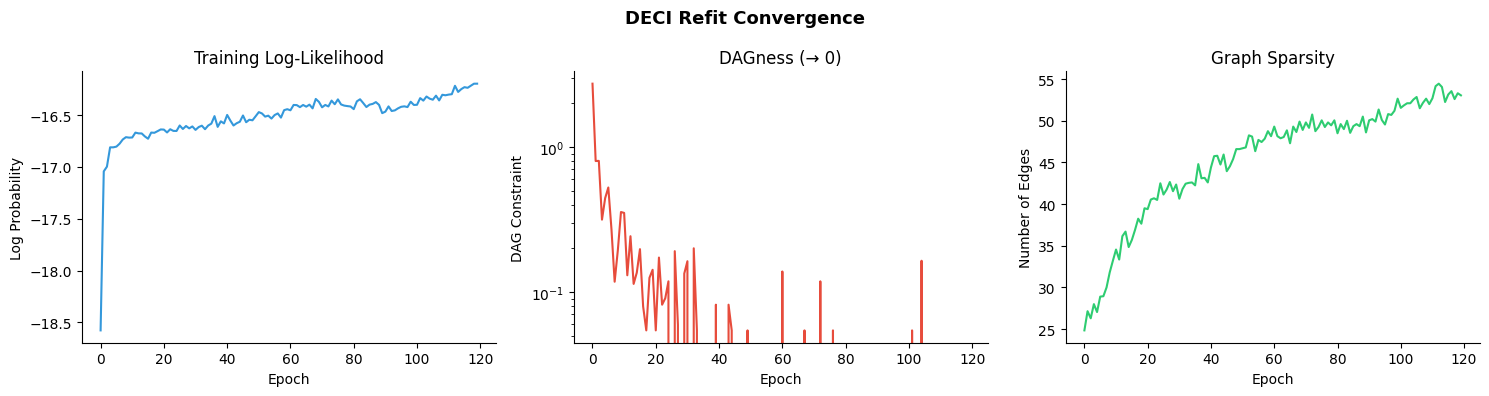

 save: deci_refit_convergence.pdf

   120  epoch
   dagness: 0.000000
   edges: 53


In [9]:
import matplotlib.pyplot as plt
# ============================================================================
# 
# ============================================================================
print("\n ...")
hist_df_full = pd.DataFrame(convergence_cb_full.history)

if len(hist_df_full) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    if 'log_prob' in hist_df_full.columns:
        axes[0].plot(hist_df_full['epoch'], hist_df_full['log_prob'], color='#3498DB')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Log Probability')
        axes[0].set_title('Training Log-Likelihood')
    
    if 'dagness' in hist_df_full.columns:
        axes[1].plot(hist_df_full['epoch'], hist_df_full['dagness'], color='#E74C3C')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('DAG Constraint')
        axes[1].set_title('DAGness (→ 0)')
        axes[1].set_yscale('log')
    
    if 'num_edges' in hist_df_full.columns:
        axes[2].plot(hist_df_full['epoch'], hist_df_full['num_edges'], color='#2ECC71')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Number of Edges')
        axes[2].set_title('Graph Sparsity')
    
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.suptitle('DECI Refit Convergence', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("deci_refit_convergence.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    print(" save: deci_refit_convergence.pdf")
    
    print(f"\n   {trainer_full.current_epoch}  epoch")
    if 'dagness' in hist_df_full.columns:
        print(f"   dagness: {hist_df_full['dagness'].iloc[-1]:.6f}")
    if 'num_edges' in hist_df_full.columns:
        print(f"   edges: {hist_df_full['num_edges'].iloc[-1]:.0f}")

In [11]:
# ============================================================================
# ============================================================================
import torch
import os
from causica.lightning.modules.deci_module import DECIModule
from causica.distributions import ContinuousNoiseDist

MODEL_WEIGHTS_PATH = "deci_model_weights_LAeq_overall_greenpro.pth"
# ---------------------------------------------------------
# ---------------------------------------------------------
torch.save(deci_model.state_dict(), MODEL_WEIGHTS_PATH)
print(f": {MODEL_WEIGHTS_PATH}")
# ---------------------------------------------------------
# ---------------------------------------------------------


: deci_model_weights_LAeq_overall_greenpro.pth


In [6]:
# ---------------------------------------------------------
# Load
# ---------------------------------------------------------
print("\n ...")

MODEL_WEIGHTS_PATH = "deci_model_weights_LAeq_overall_greenpro.pth"

loaded_deci_model = DECIModule(
    noise_dist=ContinuousNoiseDist.GAUSSIAN,
    embedding_size=32,
    prior_sparsity_lambda=0.5,
    constraint_matrix_path="structural_constraints.npy", 
)

loaded_deci_model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=torch.device('cpu')))


loaded_deci_model.eval()
print(" model loaded")

# ---------------------------------------------------------
# Sanity Check
# ---------------------------------------------------------
with torch.no_grad():
    sem_dist_loaded = loaded_deci_model.sem_module()
    sample_graph = sem_dist_loaded.sample(torch.Size([1]))
    nodes_count = sample_graph[0].graph.shape[0]
    print(f"📊  {nodes_count} nodes")


 ...
 model loaded
📊  12 nodes


In [7]:
deci_model=loaded_deci_model

Generating DAG...


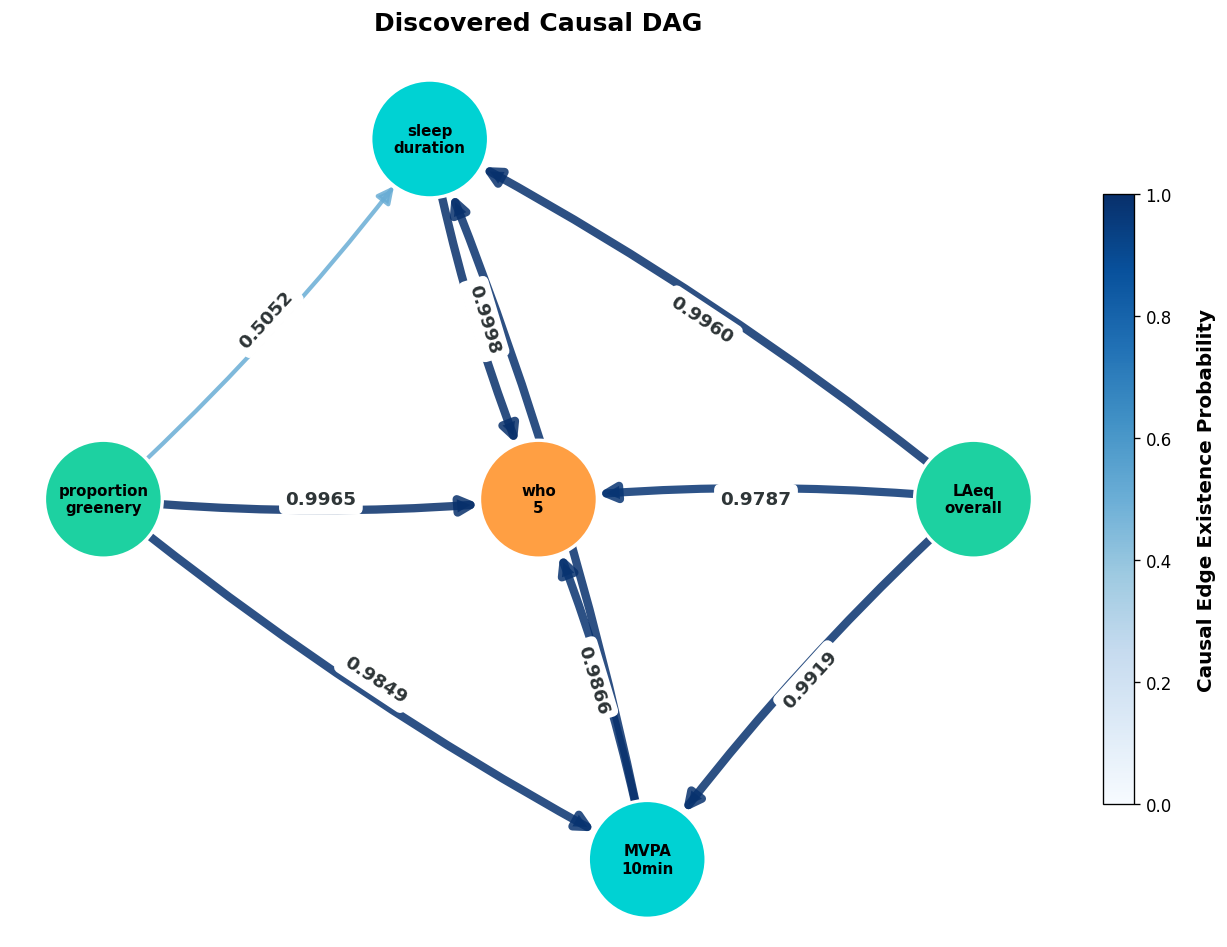

In [12]:
# Cell 3: DAG visualization
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

print("Generating DAG...")

# 1. Extract adjacency probability matrix
adj_probs = deci_model.sem_module().mean.graph.detach().cpu().numpy()

# 2. Force DAG by pruning bidirectional edges
num_nodes_total = adj_probs.shape[0]
strict_adj = adj_probs.copy()
for i in range(num_nodes_total):
    for j in range(i + 1, num_nodes_total):
        if strict_adj[i, j] > 0 and strict_adj[j, i] > 0:
            if strict_adj[i, j] >= strict_adj[j, i]:
                strict_adj[j, i] = 0.0
            else:
                strict_adj[i, j] = 0.0

# 3. Apply confidence threshold
threshold = 0.2
adj_matrix = np.where(strict_adj > threshold, strict_adj, 0)

# 4. Extract core variables
core_features = [col_Y, col_M1, col_M2, col_T_Green, col_T_Noise]
features_list = df.columns.tolist()
core_indices = [features_list.index(c) for c in core_features]
sub_matrix = np.zeros((len(core_features), len(core_features)))
for i, orig_i in enumerate(core_indices):
    for j, orig_j in enumerate(core_indices):
        sub_matrix[i, j] = adj_matrix[orig_i, orig_j]

# 5. Block T1 <-> T2 edges
t1_local_idx = core_features.index(col_T_Green)
t2_local_idx = core_features.index(col_T_Noise)
sub_matrix[t1_local_idx, t2_local_idx] = 0.0
sub_matrix[t2_local_idx, t1_local_idx] = 0.0

# 6. Build graph
fig, ax = plt.subplots(figsize=(11, 8), dpi=120)
G_core = nx.from_numpy_array(sub_matrix, create_using=nx.DiGraph)

shells_core = [
    [core_features.index(col_Y)],
    [core_features.index(col_M1), core_features.index(col_M2)],
    [core_features.index(col_T_Green), core_features.index(col_T_Noise)]
]
pos_core = nx.shell_layout(G_core, shells_core)

NODE_SIZE = 5000

color_map = {col_Y: '#ff9f43', col_M1: '#00d2d3', col_M2: '#00d2d3',
             col_T_Green: '#1dd1a1', col_T_Noise: '#1dd1a1'}
node_colors = [color_map[feat] for feat in core_features]

edges = list(G_core.edges())
weights = [sub_matrix[u, v] for u, v in edges]
edge_widths = [(w * 5) for w in weights]
edge_labels = {(u, v): f"{sub_matrix[u, v]:.4f}" for u, v in edges}

# Draw nodes
nx.draw_networkx_nodes(G_core, pos_core, node_color=node_colors,
                       node_size=NODE_SIZE, edgecolors='white', linewidths=2, ax=ax)

# Draw edges
nx.draw_networkx_edges(
    G_core, pos_core,
    edgelist=edges,
    width=edge_widths,
    alpha=0.85,
    edge_color=weights,
    edge_cmap=cm.Blues,
    edge_vmin=0.0,
    edge_vmax=1.0,
    arrowsize=20,
    arrowstyle='-|>',
    node_size=NODE_SIZE,
    connectionstyle='arc3,rad=0.05',
    ax=ax
)

# Node labels wrapped at "_"
display_labels = {i: core_features[i].replace("_", "\n") for i in range(len(core_features))}
nx.draw_networkx_labels(G_core, pos_core, labels=display_labels,
                        font_size=9, font_weight='bold', ax=ax)

# Edge probability labels
nx.draw_networkx_edge_labels(G_core, pos_core, edge_labels=edge_labels,
                             font_color='#2d3436', font_size=11,
                             font_weight='bold', ax=ax)

# Colorbar
sm = cm.ScalarMappable(cmap=cm.Blues, norm=mcolors.Normalize(vmin=0.0, vmax=1.0))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.03)
cbar.set_label('Causal Edge Existence Probability',
               fontsize=12, fontweight='bold', labelpad=15)

plt.title("Discovered Causal DAG", fontsize=15, pad=20, fontweight='bold')
ax.axis('off')
plt.tight_layout()
fig.savefig("Discovered_Causal_DAG.pdf", format='pdf', bbox_inches='tight')
plt.show()

Saved: structural_constraints_prior.pdf / .png


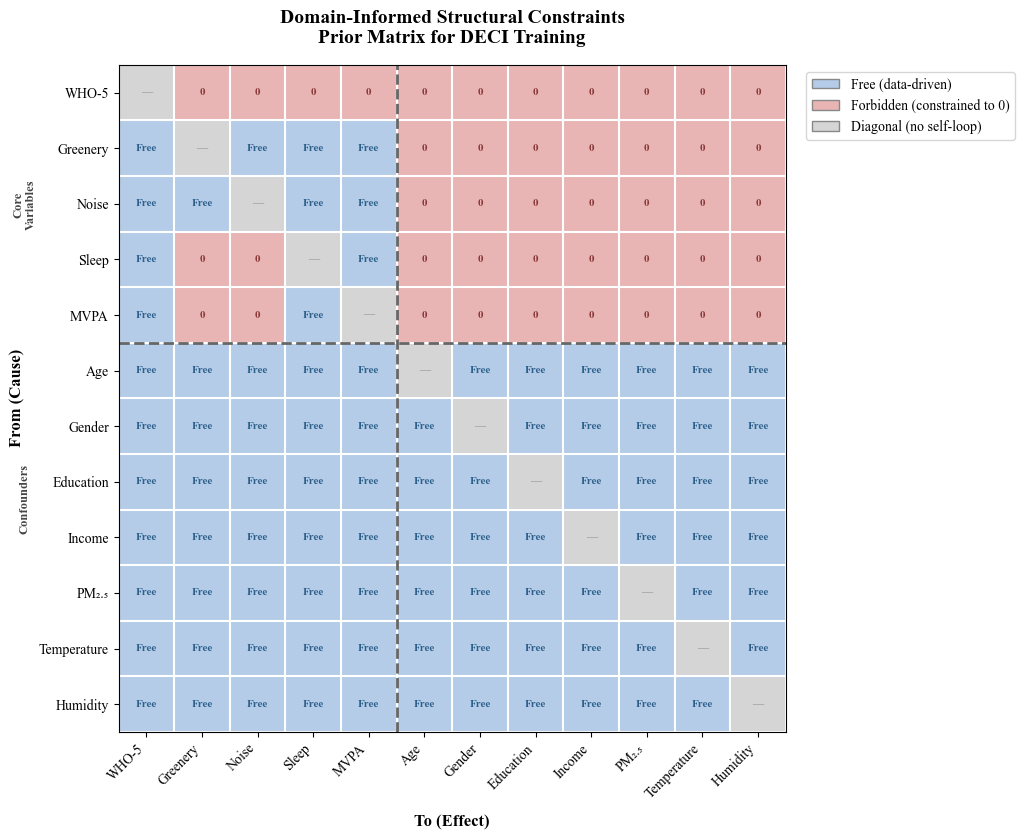

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Liberation Serif', 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

# ============================================================================
# 1. Reconstruct the constraint matrix exactly as in your training code
# ============================================================================

col_Y = 'who_5'
col_T_Green = 'proportion_greenery'
col_T_Noise = 'LAeq_overall'
col_M1 = 'sleep_duration'
col_M2 = 'MVPA_10min'
cols_W = ["age", "gender", "education_level", "family_income",
          "PM2_5", "temperature", "humidity"]

all_cols = [col_Y, col_T_Green, col_T_Noise, col_M1, col_M2] + cols_W
features = all_cols
num_nodes = len(features)

# Initialize: NaN = unconstrained (data-driven)
constraints = np.full((num_nodes, num_nodes), np.nan, dtype=np.float32)

idx_Y = [features.index(col_Y)]
idx_M = [features.index(col_M1), features.index(col_M2)]
idx_T = [features.index(col_T_Green), features.index(col_T_Noise)]
idx_W = [features.index(c) for c in cols_W]

# Confounders cannot be caused by T, M, Y
for i in idx_M + idx_T + idx_Y:
    for j in idx_W:
        constraints[i, j] = 0.0

# Treatments cannot be caused by M or Y
for i in idx_M + idx_Y:
    for j in idx_T:
        constraints[i, j] = 0.0

# Mediators cannot be caused by Y
for i in idx_Y:
    for j in idx_M:
        constraints[i, j] = 0.0

# No self-loops
np.fill_diagonal(constraints, 0.0)

# ============================================================================
# 2. Display labels
# ============================================================================

display_names = {
    'who_5': 'WHO-5',
    'proportion_greenery': 'Greenery',
    'LAeq_overall': 'Noise',
    'sleep_duration': 'Sleep',
    'MVPA_10min': 'MVPA',
    'age': 'Age',
    'gender': 'Gender',
    'education_level': 'Education',
    'family_income': 'Income',
    'PM2_5': 'PM₂.₅',
    'temperature': 'Temperature',
    'humidity': 'Humidity',
}

labels = [display_names[c] for c in features]

# ============================================================================
# 3. Plot heatmap
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8.5))

# Custom colormap: 0 = forbidden (red), NaN = free (blue), diagonal = grey
# Create a display matrix: 0 -> 0, NaN -> 1, diagonal -> -1
display_mat = np.zeros_like(constraints)
for i in range(num_nodes):
    for j in range(num_nodes):
        if i == j:
            display_mat[i, j] = -1   # diagonal
        elif np.isnan(constraints[i, j]):
            display_mat[i, j] = 1    # free / data-driven
        else:
            display_mat[i, j] = 0    # forbidden

# Custom colormap: grey, red, blue
cmap = mcolors.ListedColormap(['#D5D5D5', '#E8B4B4', '#B4CCE8'])
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(display_mat, cmap=cmap, norm=norm, aspect='equal')

# Grid lines
for i in range(num_nodes + 1):
    ax.axhline(i - 0.5, color='white', linewidth=1.5)
    ax.axvline(i - 0.5, color='white', linewidth=1.5)

# Separate core (5) vs confounders (7) with thicker lines
ax.axhline(5 - 0.5, color='#666', linewidth=2, linestyle='--')
ax.axvline(5 - 0.5, color='#666', linewidth=2, linestyle='--')

# Cell annotations
for i in range(num_nodes):
    for j in range(num_nodes):
        if i == j:
            txt = '—'
            color = '#999'
        elif np.isnan(constraints[i, j]):
            txt = 'Free'
            color = '#2C5F8A'
        else:
            txt = '0'
            color = '#8B3A3A'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=8, fontweight='bold', color=color)

# Axis labels
ax.set_xticks(range(num_nodes))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(num_nodes))
ax.set_yticklabels(labels, fontsize=10)

ax.set_xlabel('To (Effect)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('From (Cause)', fontsize=12, fontweight='bold', labelpad=10)
ax.xaxis.set_label_position('bottom')

# Title
ax.set_title('Domain-Informed Structural Constraints\n'
             'Prior Matrix for DECI Training',
             fontsize=14, fontweight='bold', pad=16)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#B4CCE8', edgecolor='#888', label='Free (data-driven)'),
    Patch(facecolor='#E8B4B4', edgecolor='#888', label='Forbidden (constrained to 0)'),
    Patch(facecolor='#D5D5D5', edgecolor='#888', label='Diagonal (no self-loop)'),
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), fontsize=10,
          frameon=True, edgecolor='#ccc')

# Bracket labels on the side
ax.annotate('Core\nVariables', xy=(-0.14, 0.79), xycoords='axes fraction',
            fontsize=9, fontweight='bold', color='#444',
            ha='center', va='center', rotation=90)
ax.annotate('Confounders', xy=(-0.14, 0.35), xycoords='axes fraction',
            fontsize=9, fontweight='bold', color='#444',
            ha='center', va='center', rotation=90)

plt.tight_layout()
plt.savefig('structural_constraints_prior.pdf',
            format='pdf', bbox_inches='tight')
plt.savefig('structural_constraints_prior.png',
            format='png', bbox_inches='tight', dpi=600)
print("Saved: structural_constraints_prior.pdf / .png")


  config: SEM × 50, MC × 2000, Grid × 100
  sampling 50  SEM

  Greenery → WHO-5 (Total effect) ... 2178.9s
    T range: [0.49, 27.54]
    effect at max: 1.534 WHO-5

  Greenery → Sleep ... 2191.5s
    T range: [0.49, 27.54]
    effect at max: 0.006 Sleep Duration (hours)

  Greenery → MVPA ... 2202.6s
    T range: [0.49, 27.54]
    effect at max: 0.268 MVPA (minutes)

  Noise → WHO-5 (Total effect) ... 2203.6s
    T range: [46.74, 101.05]
    effect at max: -0.692 WHO-5

  Noise → Sleep ... 2211.4s
    T range: [46.74, 101.05]
    effect at max: -0.132 Sleep Duration (hours)

  Noise → MVPA ... 2214.8s
    T range: [46.74, 101.05]
    effect at max: 8.117 MVPA (minutes)

  Sleep → WHO-5 ... 2217.1s
    T range: [2.90, 10.85]
    effect at max: -0.628 WHO-5

  MVPA → WHO-5 ... 2176.6s
    T range: [0.00, 104.17]
    effect at max: 0.053 WHO-5

...


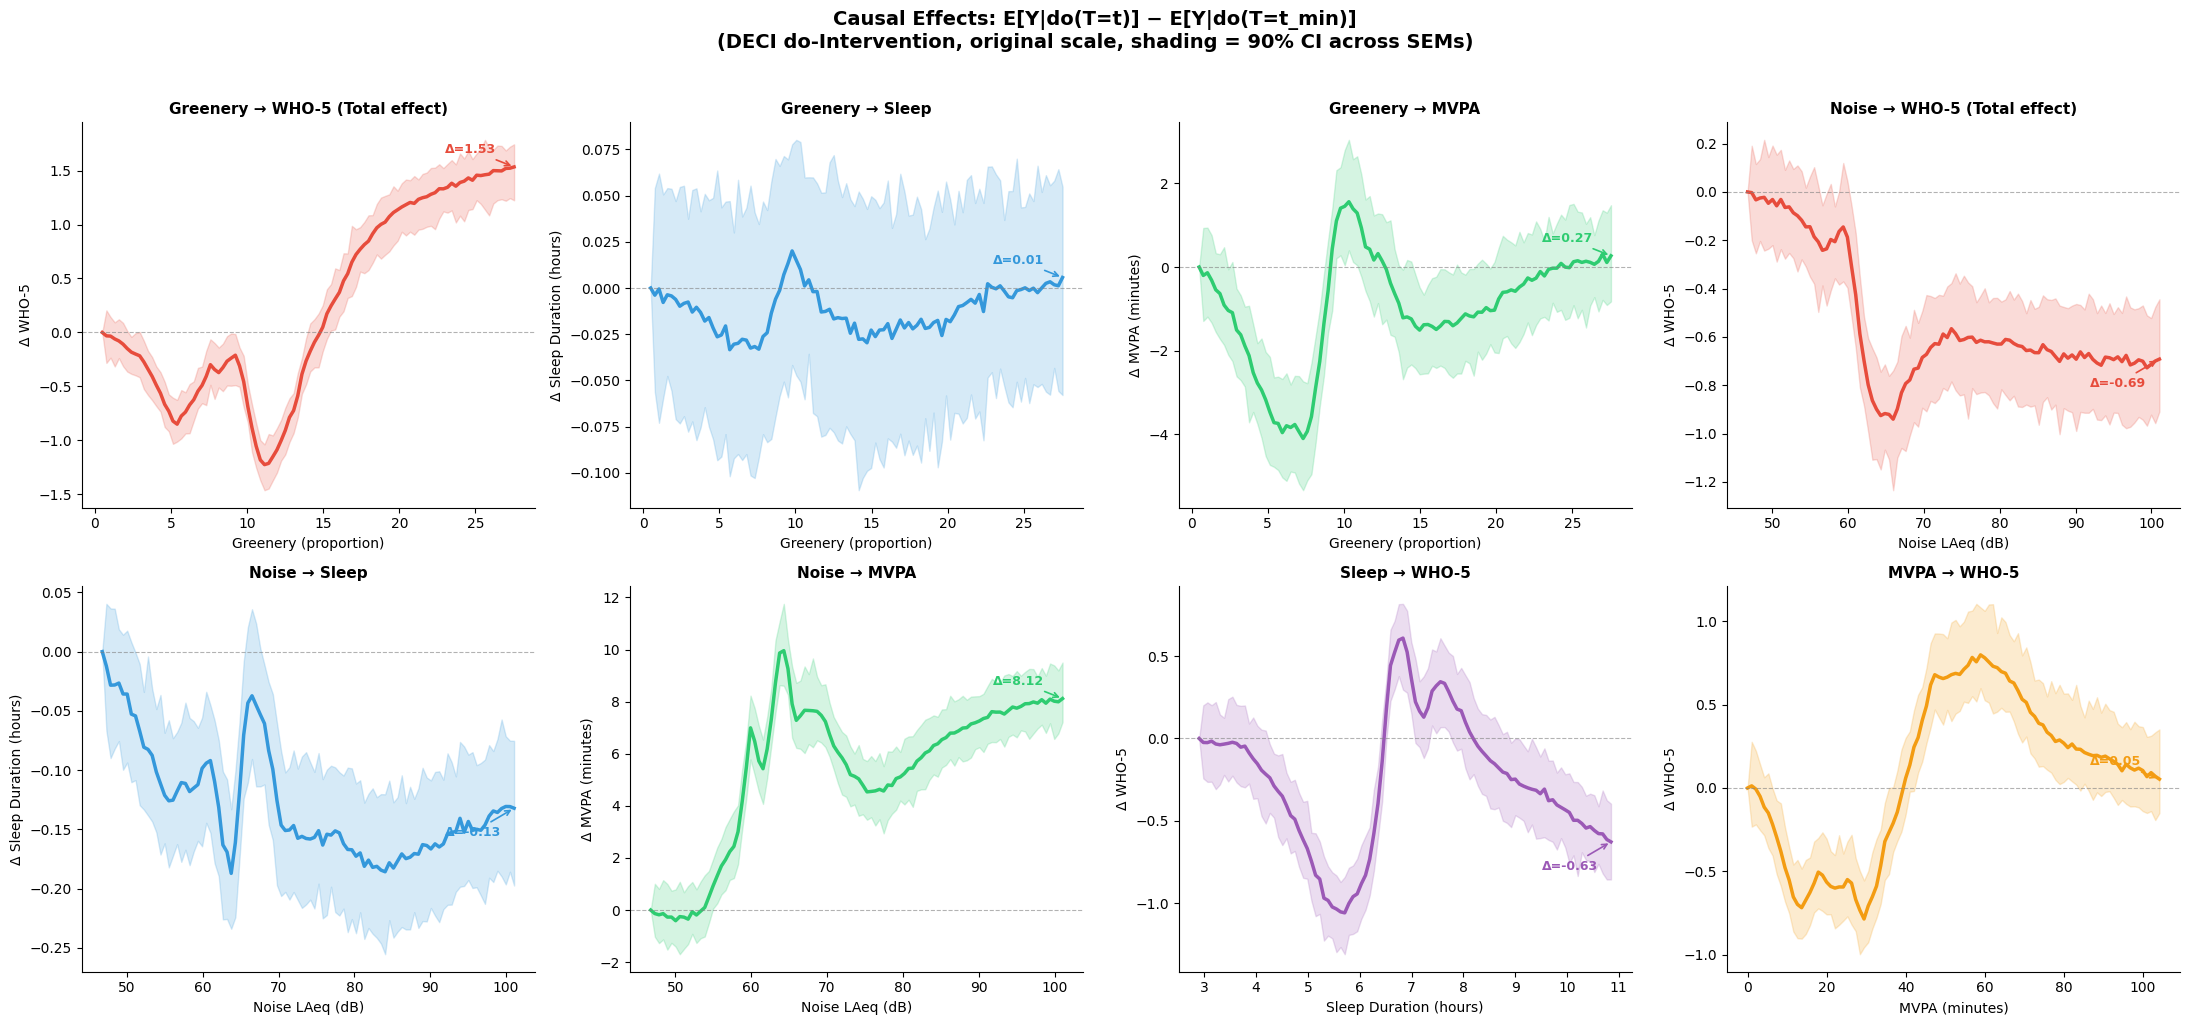

  : dose_response_8paths.pdf


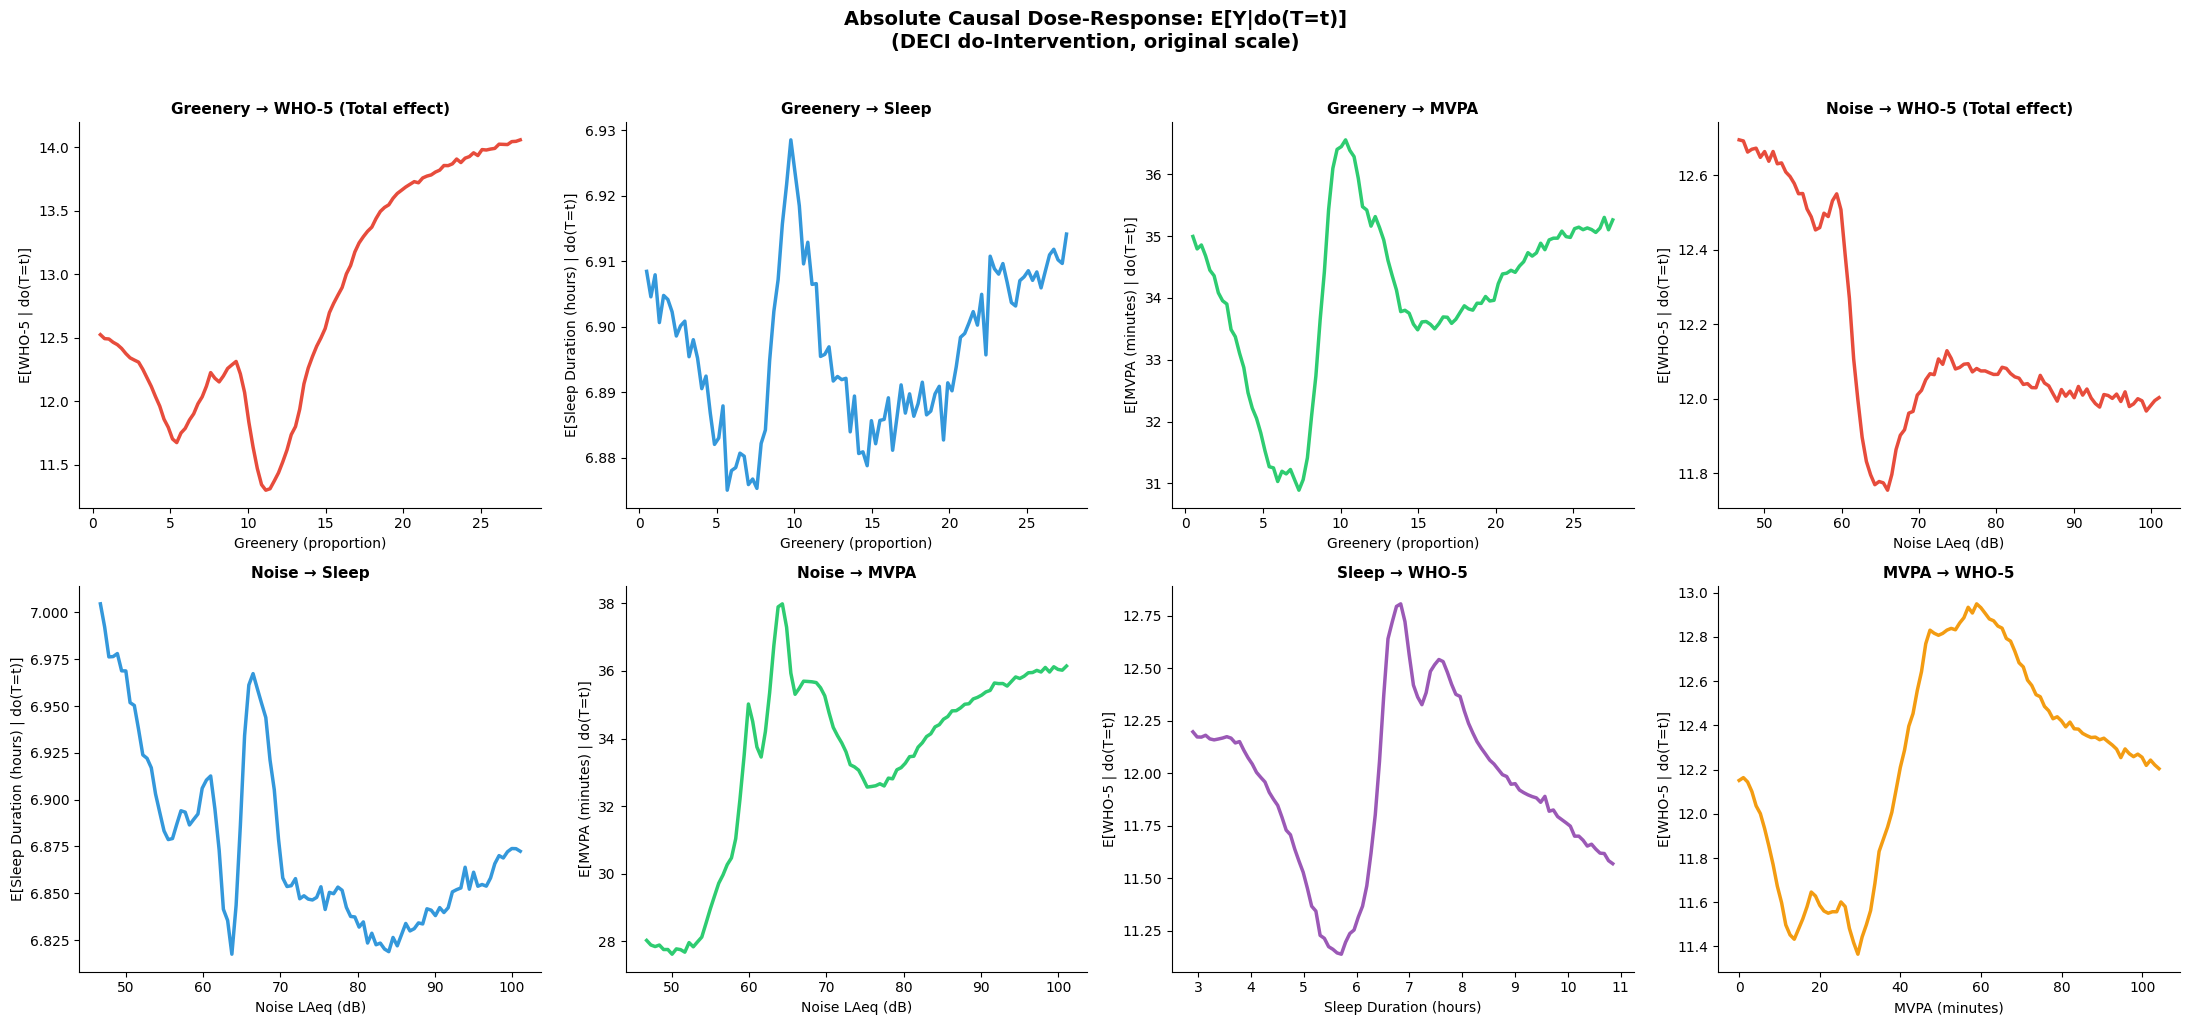

  : dose_response_absolute.pdf


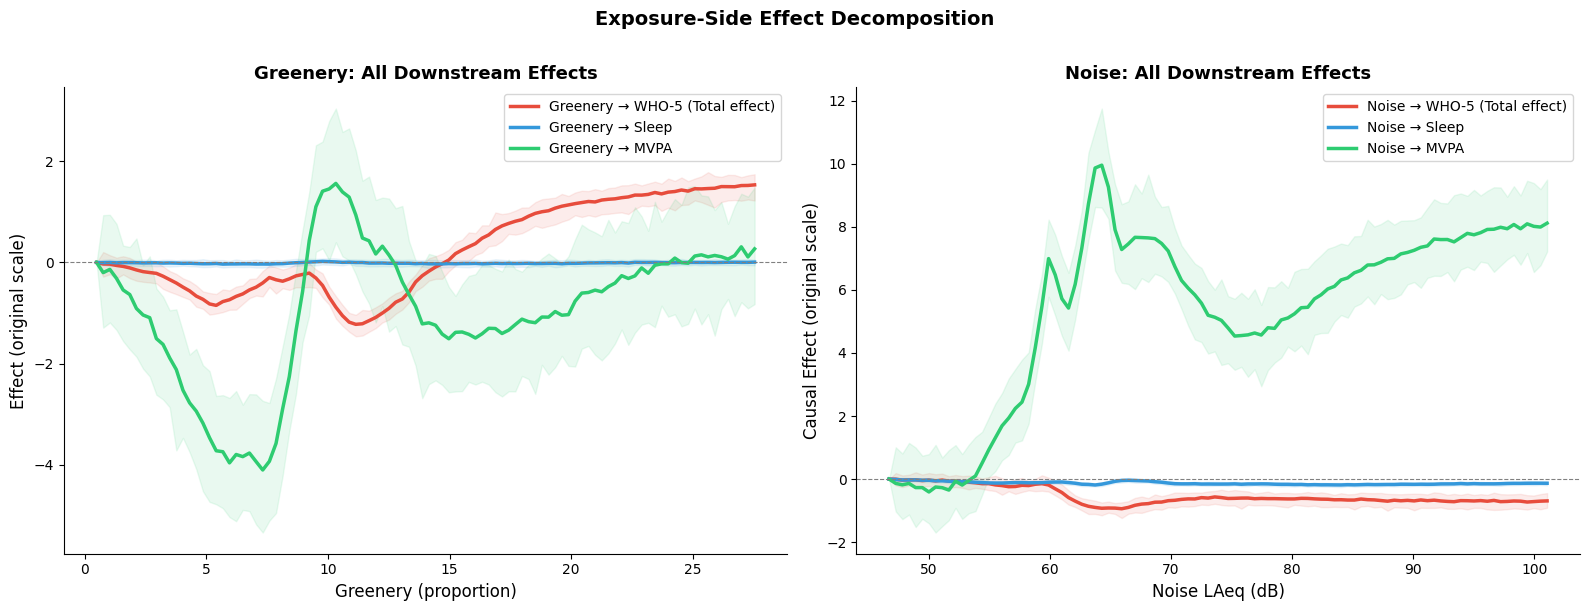

  : dose_response_by_exposure.pdf

 done！
    dose_response_8paths.pdf
   dose_response_absolute.pdf
   dose_response_by_exposure.pdf
   dose_T1_Y.csv ... dose_M2_Y.csv


In [14]:
# ============================================================================
# ============================================================================
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from tensordict import TensorDict
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("=" * 70)

# ============================================================================
# ============================================================================

NUM_SEM = 50#50
N_MC = 2000#2000
N_GRID = 100#100

# ============================================================================
# ============================================================================

def make_interv(var_name, value):
    return TensorDict({var_name: torch.tensor([float(value)])}, batch_size=[])

def std_to_raw(val_std, var_name):
    idx = all_cols.index(var_name)
    return val_std * scaler.scale_[idx] + scaler.mean_[idx]

def effect_to_raw(eff_std, outcome_var):
    idx = all_cols.index(outcome_var)
    return eff_std * scaler.scale_[idx]

def get_var_range_std(var_name):
    idx = all_cols.index(var_name)
    raw_min = df_raw[var_name].min()
    raw_max = df_raw[var_name].max()
    std_min = (raw_min - scaler.mean_[idx]) / scaler.scale_[idx]
    std_max = (raw_max - scaler.mean_[idx]) / scaler.scale_[idx]
    return std_min, std_max

# ============================================================================
# sampling SEM
# ============================================================================

print(f"\n  config: SEM × {NUM_SEM}, MC × {N_MC}, Grid × {N_GRID}")

deci_model.eval()
with torch.no_grad():
    sems = list(deci_model.sem_module().sample(torch.Size([NUM_SEM])))
print(f"  sampling {NUM_SEM}  SEM")

# ============================================================================
# ============================================================================

paths = [
    (col_T_Green, col_Y,  "T1→Y",  "Greenery → WHO-5 (Total effect)"),
    (col_T_Green, col_M1, "T1→M1", "Greenery → Sleep"),
    (col_T_Green, col_M2, "T1→M2", "Greenery → MVPA"),
    (col_T_Noise, col_Y,  "T2→Y",  "Noise → WHO-5 (Total effect)"),
    (col_T_Noise, col_M1, "T2→M1", "Noise → Sleep"),
    (col_T_Noise, col_M2, "T2→M2", "Noise → MVPA"), 
    (col_M1,      col_Y,  "M1→Y",  "Sleep → WHO-5"),
    (col_M2,      col_Y,  "M2→Y",  "MVPA → WHO-5"),
]


var_labels = {
    col_T_Green: "Greenery (proportion)",
    col_T_Noise: "Noise LAeq (dB)",
    col_M1: "Sleep Duration (hours)",
    col_M2: "MVPA (minutes)",
    col_Y: "WHO-5",
}

# ============================================================================
# ============================================================================

all_dose_results = {}

for treat_var, outcome_var, short_name, desc in paths:
    t0 = time.time()
    print(f"\n  {desc} ...", end=" ", flush=True)
    

    t_min_std, t_max_std = get_var_range_std(treat_var)
    

    t_grid_std = np.linspace(t_min_std, t_max_std, N_GRID)
    

    y_per_sem = np.zeros((NUM_SEM, N_GRID))
    
    for s_idx, sem in enumerate(sems):
        with torch.no_grad():
            for g_idx, t_val in enumerate(t_grid_std):
                samples = sem.do(make_interv(treat_var, t_val)).sample(torch.Size([N_MC]))
                y_per_sem[s_idx, g_idx] = samples[outcome_var].mean().item()
    

    y_baseline = y_per_sem[:, 0:1]  # (NUM_SEM, 1)
    

    effect_std = y_per_sem - y_baseline  # (NUM_SEM, N_GRID)
    

    effect_mean_std = effect_std.mean(axis=0)   # (N_GRID,)
    effect_lower_std = np.percentile(effect_std, 5, axis=0)
    effect_upper_std = np.percentile(effect_std, 95, axis=0)
    
    t_grid_raw = np.array([std_to_raw(t, treat_var) for t in t_grid_std])
    effect_mean_raw = np.array([effect_to_raw(e, outcome_var) for e in effect_mean_std])
    effect_lower_raw = np.array([effect_to_raw(e, outcome_var) for e in effect_lower_std])
    effect_upper_raw = np.array([effect_to_raw(e, outcome_var) for e in effect_upper_std])
    
    #  E[Y|do(T=t)]
    y_mean_std = y_per_sem.mean(axis=0)
    y_mean_raw = np.array([std_to_raw(y, outcome_var) for y in y_mean_std])
    
    elapsed = time.time() - t0
    print(f"{elapsed:.1f}s")
    

    all_dose_results[short_name] = {
        'treat_var': treat_var,
        'outcome_var': outcome_var,
        'desc': desc,
        't_grid_std': t_grid_std,
        't_grid_raw': t_grid_raw,
        'effect_mean_raw': effect_mean_raw,
        'effect_lower_raw': effect_lower_raw,
        'effect_upper_raw': effect_upper_raw,
        'y_absolute_raw': y_mean_raw,
        'effect_per_sem_std': effect_std,  
    }
    

    max_effect = effect_mean_raw[-1]
    print(f"    T range: [{t_grid_raw[0]:.2f}, {t_grid_raw[-1]:.2f}]")
    print(f"    effect at max: {max_effect:.3f} {var_labels[outcome_var]}")

# ============================================================================
# ============================================================================

print("\n...")


fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

path_colors = {
    'T1→Y': '#E74C3C', 'T1→M1': '#3498DB', 'T1→M2': '#2ECC71',
    'T2→Y': '#E74C3C', 'T2→M1': '#3498DB', 'T2→M2': '#2ECC71',
    'M1→Y': '#9B59B6', 'M2→Y': '#F39C12',
}

for i, (treat_var, outcome_var, short_name, desc) in enumerate(paths):
    d = all_dose_results[short_name]
    ax = axes[i]
    
    color = path_colors[short_name]
    ax.plot(d['t_grid_raw'], d['effect_mean_raw'], color=color, linewidth=2.5)
    ax.fill_between(d['t_grid_raw'], d['effect_lower_raw'], d['effect_upper_raw'],
                    alpha=0.2, color=color)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    

    max_eff = d['effect_mean_raw'][-1]
    ax.annotate(f'Δ={max_eff:.2f}', 
                xy=(d['t_grid_raw'][-1], max_eff),
                xytext=(-50, 10 if max_eff > 0 else -20),
                textcoords='offset points',
                fontsize=9, fontweight='bold', color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    
    ax.set_xlabel(var_labels[treat_var], fontsize=10)
    ax.set_ylabel(f'Δ {var_labels[outcome_var]}', fontsize=10)
    ax.set_title(desc, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Causal Effects: E[Y|do(T=t)] − E[Y|do(T=t_min)]\n'
             '(DECI do-Intervention, original scale, shading = 90% CI across SEMs)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("dose_response_8paths_coh.pdf", format='pdf', bbox_inches='tight')
plt.show()
print("  : dose_response_8paths.pdf")


fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

for i, (treat_var, outcome_var, short_name, desc) in enumerate(paths):
    d = all_dose_results[short_name]
    ax = axes[i]
    color = path_colors[short_name]
    
    ax.plot(d['t_grid_raw'], d['y_absolute_raw'], color=color, linewidth=2.5)
    ax.set_xlabel(var_labels[treat_var], fontsize=10)
    ax.set_ylabel(f'E[{var_labels[outcome_var]} | do(T=t)]', fontsize=10)
    ax.set_title(desc, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Absolute Causal Dose-Response: E[Y|do(T=t)]\n'
             '(DECI do-Intervention, original scale)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("dose_response_absolute_coh.pdf", format='pdf', bbox_inches='tight')
plt.show()
print("  : dose_response_absolute.pdf")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


ax = axes[0]
for sn in ['T1→Y', 'T1→M1', 'T1→M2']:
    d = all_dose_results[sn]
    ax.plot(d['t_grid_raw'], d['effect_mean_raw'], linewidth=2.5,
            color=path_colors[sn], label=d['desc'])
    ax.fill_between(d['t_grid_raw'], d['effect_lower_raw'], d['effect_upper_raw'],
                    alpha=0.1, color=path_colors[sn])
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel(var_labels[col_T_Green], fontsize=12)
ax.set_ylabel('Effect (original scale)', fontsize=12)
ax.set_title('Greenery: All Downstream Effects', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax = axes[1]
for sn in ['T2→Y', 'T2→M1', 'T2→M2']:
    d = all_dose_results[sn]
    ax.plot(d['t_grid_raw'], d['effect_mean_raw'], linewidth=2.5,
            color=path_colors[sn], label=d['desc'])
    ax.fill_between(d['t_grid_raw'], d['effect_lower_raw'], d['effect_upper_raw'],
                    alpha=0.1, color=path_colors[sn])
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel(var_labels[col_T_Noise], fontsize=12)
ax.set_ylabel('Causal Effect (original scale)', fontsize=12)
ax.set_title('Noise: All Downstream Effects', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Exposure-Side Effect Decomposition',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("dose_response_by_exposure_coh.pdf", format='pdf', bbox_inches='tight')
plt.show()
print("  : dose_response_by_exposure.pdf")

# ============================================================================
# ============================================================================

for short_name, d in all_dose_results.items():
    df_out = pd.DataFrame({
        f'{d["treat_var"]}_raw': d['t_grid_raw'],
        f'effect_on_{d["outcome_var"]}_mean': d['effect_mean_raw'],
        f'effect_on_{d["outcome_var"]}_lower': d['effect_lower_raw'],
        f'effect_on_{d["outcome_var"]}_upper': d['effect_upper_raw'],
        f'{d["outcome_var"]}_absolute': d['y_absolute_raw'],
    })
    df_out.to_csv(f"dose_{short_name.replace('→','_')}.csv", index=False)

print("\n done！")
print(f"    dose_response_8paths.pdf")
print(f"   dose_response_absolute.pdf")
print(f"   dose_response_by_exposure.pdf")
print(f"   dose_T1_Y.csv ... dose_M2_Y.csv")
print("=" * 70)

🔍 Part 2: heterogeneous dose-response
  SEM × 50, MC × 2000, Treat grid × 50, Modifier levels × 5

  ⏳ A) Greenery → WHO-5, stratified by Noise ... 5556s

  ⏳ B) Noise → WHO-5, stratified by Greenery ... 5563s

  ⏳ C) Sleep → WHO-5, stratified by MVPA ... 5907s

  ⏳ D) MVPA → WHO-5, stratified by Sleep ... 6113s


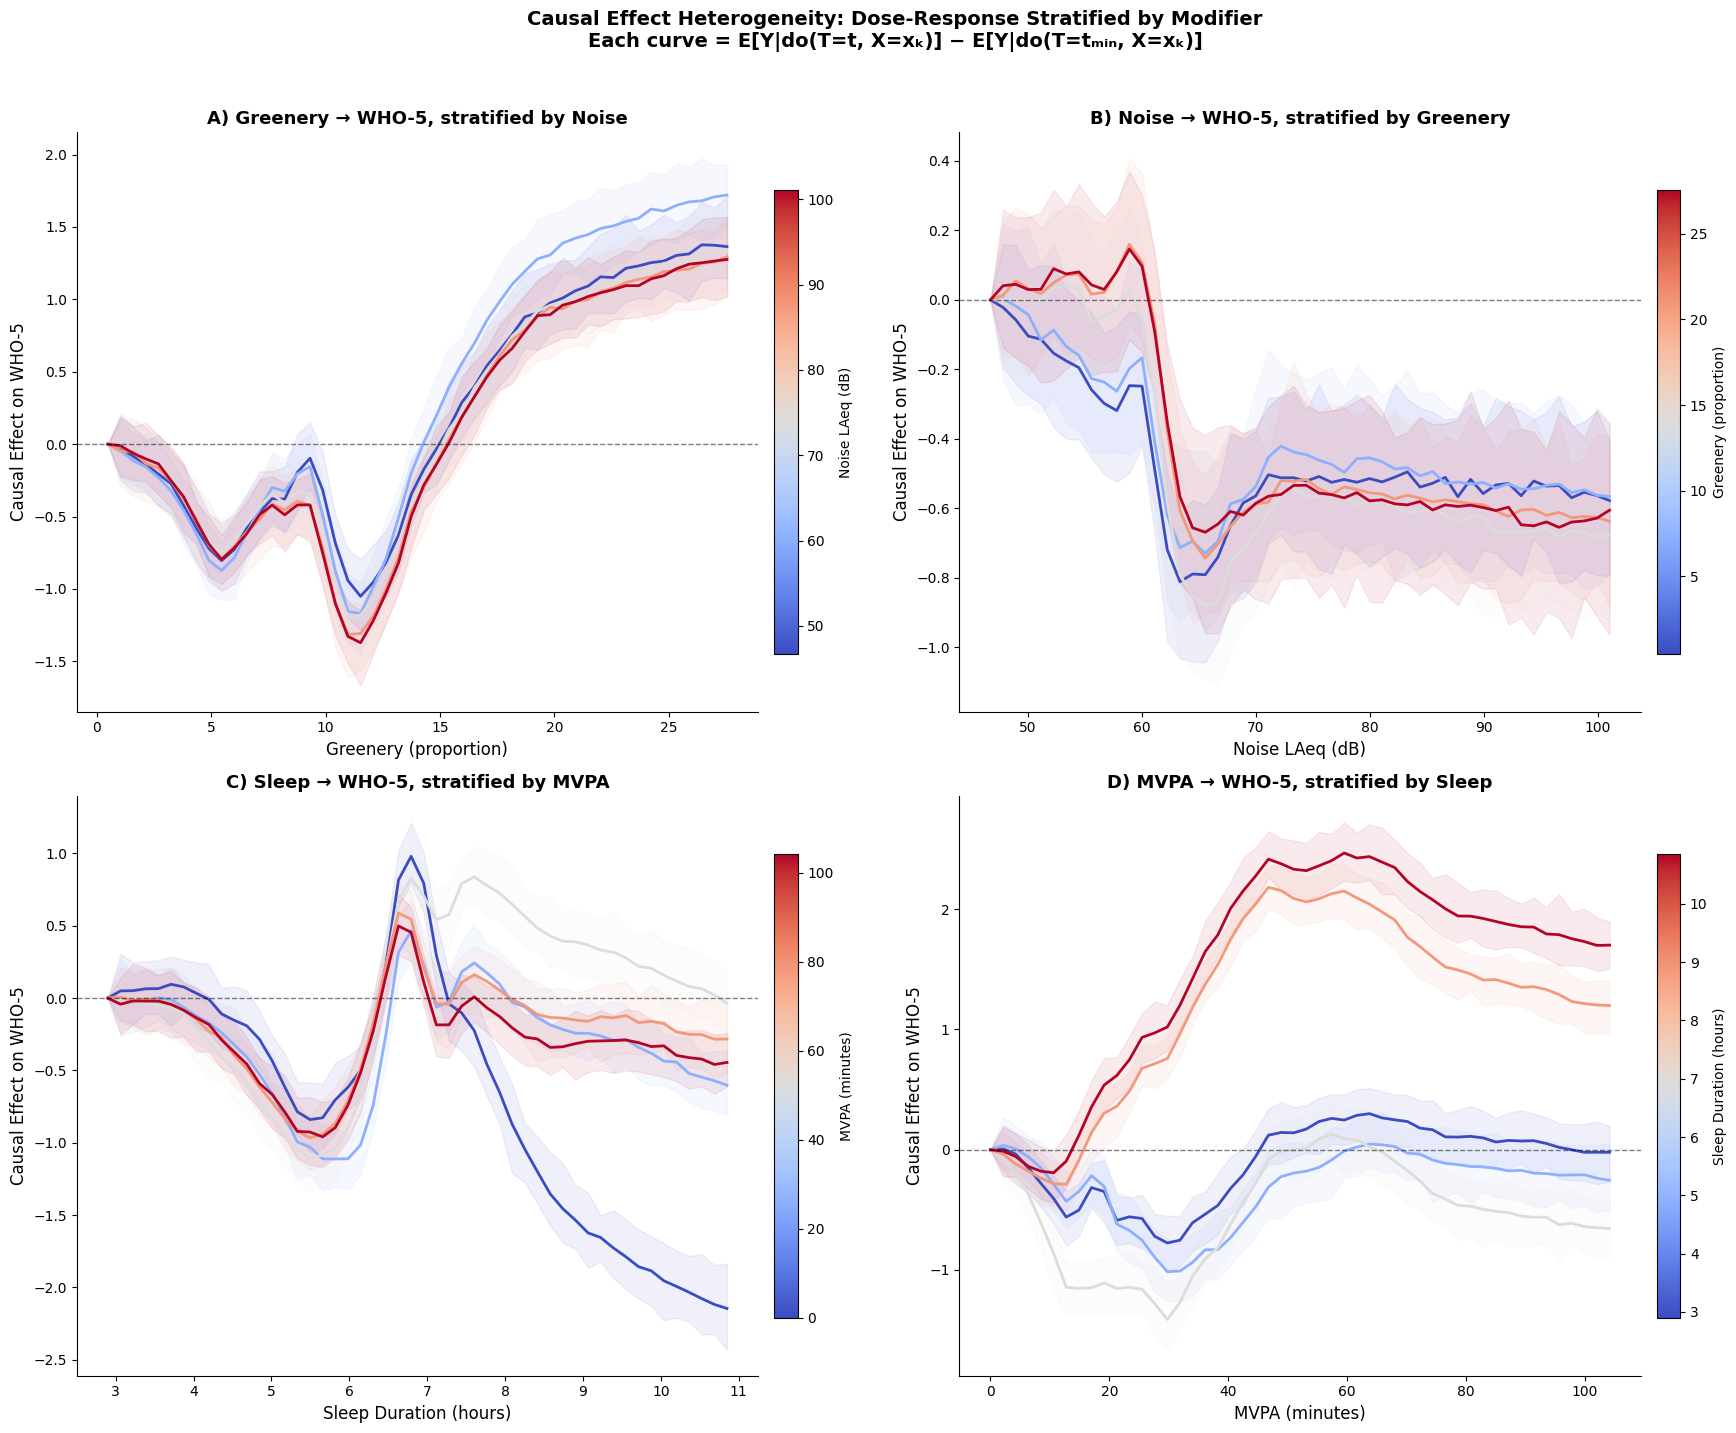


 save: heterogeneity_stratified_dose_response.pdf


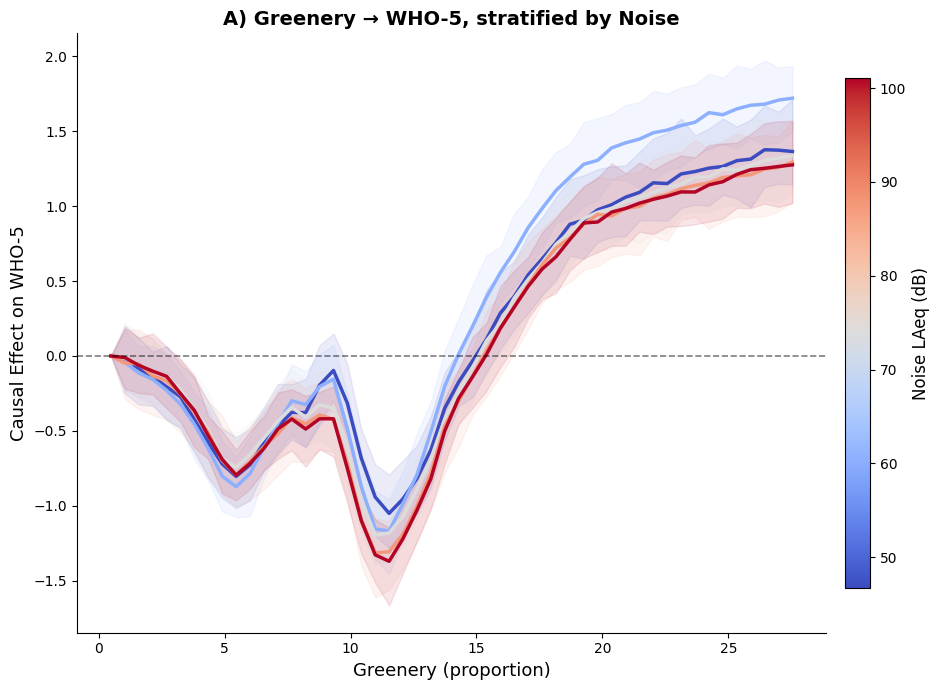

  save: het_Greenery_effect_across_Noise_levels.png


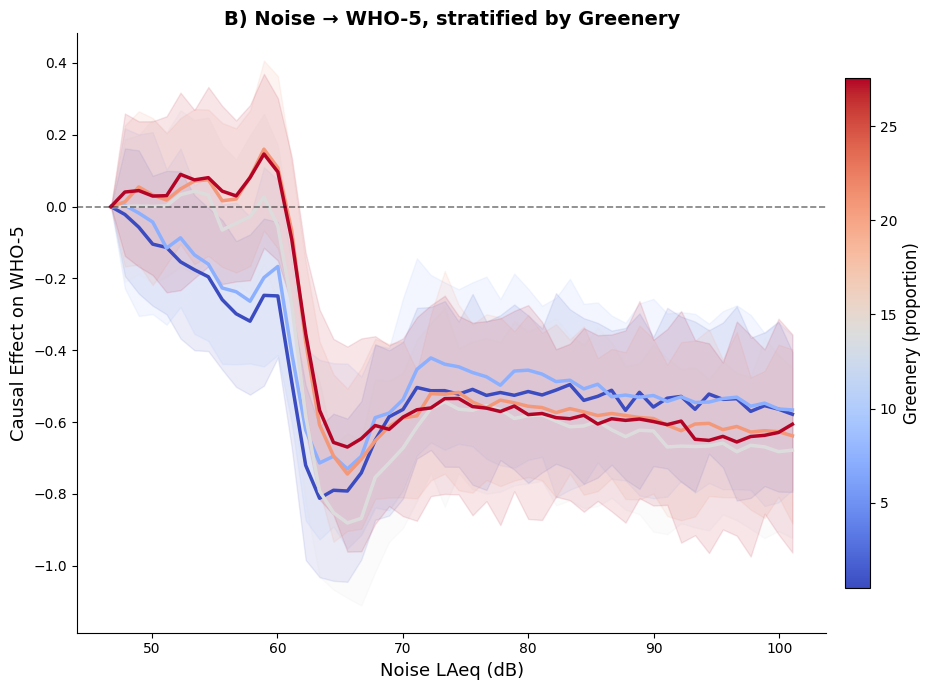

  save: het_Noise_effect_across_Greenery_levels.png


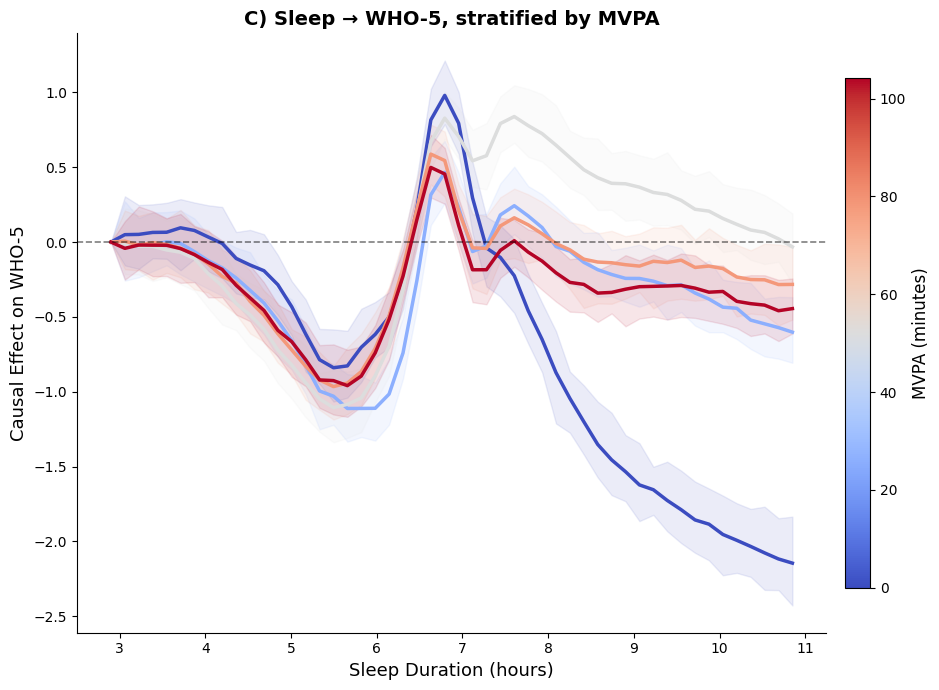

  save: het_Sleep_effect_across_MVPA_levels.png


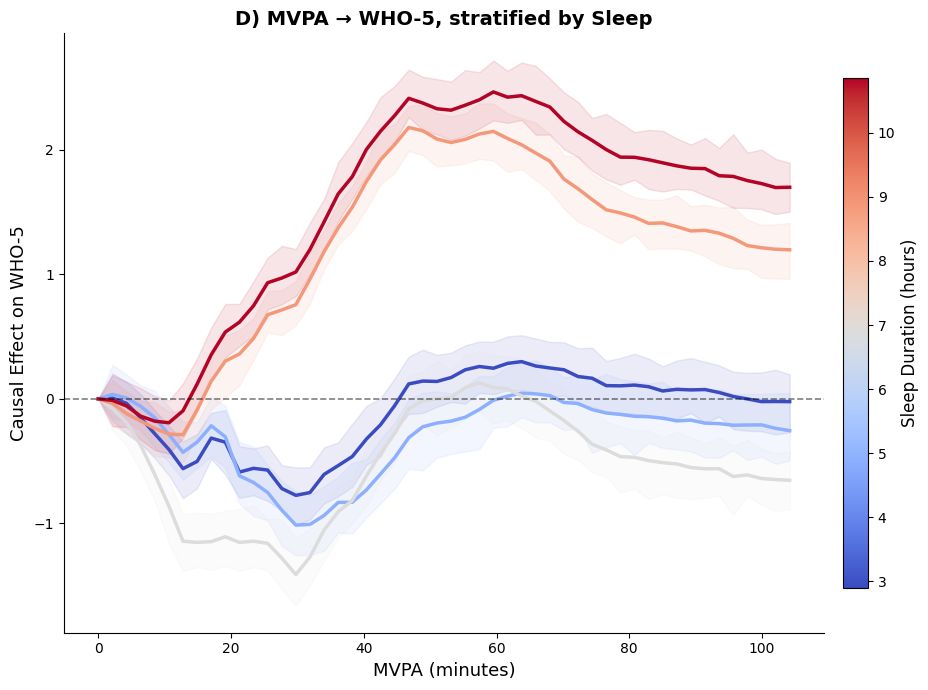

  save: het_MVPA_effect_across_Sleep_levels.png

 Part 2 !
   4group × 5m × 50t × 50SEM = 50000  do calculas


In [4]:
# heterogeneous dose-response
# ============================================================================
# ============================================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from tensordict import TensorDict
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("🔍 Part 2: heterogeneous dose-response")
print("=" * 70)

# ============================================================================
# ============================================================================

NUM_SEM = 50
N_MC = 2000
N_TREAT = 50  
N_MOD = 5    

# ============================================================================
# ============================================================================

def make_joint_interv(var_dict):
    return TensorDict({k: torch.tensor([float(v)]) for k, v in var_dict.items()},
                      batch_size=[])

def std_to_raw(val_std, var_name):
    idx = all_cols.index(var_name)
    return val_std * scaler.scale_[idx] + scaler.mean_[idx]

def effect_to_raw(eff_std, outcome_var):
    idx = all_cols.index(outcome_var)
    return eff_std * scaler.scale_[idx]

def get_var_range_std(var_name):
    idx = all_cols.index(var_name)
    raw_min = df_raw[var_name].min()
    raw_max = df_raw[var_name].max()
    std_min = (raw_min - scaler.mean_[idx]) / scaler.scale_[idx]
    std_max = (raw_max - scaler.mean_[idx]) / scaler.scale_[idx]
    return std_min, std_max

var_labels = {
    col_T_Green: "Greenery (proportion)",
    col_T_Noise: "Noise LAeq (dB)",
    col_M1: "Sleep Duration (hours)",
    col_M2: "MVPA (minutes)",
    col_Y: "WHO-5",
}

# ============================================================================
# ============================================================================

deci_model.eval()
with torch.no_grad():
    sems = list(deci_model.sem_module().sample(torch.Size([NUM_SEM])))
print(f"  SEM × {NUM_SEM}, MC × {N_MC}, Treat grid × {N_TREAT}, Modifier levels × {N_MOD}")

# ============================================================================
# ============================================================================

def stratified_dose_response(sems, treat_var, modifier_var, outcome_var,
                              n_treat, n_mod, n_mc):
    """
    
    E[Y | do(T=t_i, X=x_k)]
    effect(t_i, x_k) = E[Y|do(T=t_i, X=x_k)] - E[Y|do(T=t_min, X=x_k)]
    
      t_grid_raw: (n_treat,) 
      mod_grid_raw: (n_mod,) 
      effect_mean: (n_mod, n_treat) 
      effect_lower: (n_mod, n_treat) 2.5%
      effect_upper: (n_mod, n_treat) 97.5%
    """
    t_min_std, t_max_std = get_var_range_std(treat_var)
    x_min_std, x_max_std = get_var_range_std(modifier_var)
    
    t_grid_std = np.linspace(t_min_std, t_max_std, n_treat)
    mod_grid_std = np.linspace(x_min_std, x_max_std, n_mod)
    
    # (NUM_SEM, n_mod, n_treat)
    y_all = np.zeros((len(sems), n_mod, n_treat))
    
    for s_idx, sem in enumerate(sems):
        with torch.no_grad():
            for m_idx, x_val in enumerate(mod_grid_std):
                for t_idx, t_val in enumerate(t_grid_std):
                    interv = make_joint_interv({
                        treat_var: float(t_val),
                        modifier_var: float(x_val)
                    })
                    samples = sem.do(interv).sample(torch.Size([n_mc]))
                    y_all[s_idx, m_idx, t_idx] = samples[outcome_var].mean().item()
    
    baseline = y_all[:, :, 0:1]  # (NUM_SEM, n_mod, 1)
    effect_std = y_all - baseline  # (NUM_SEM, n_mod, n_treat)
    
    effect_mean = effect_to_raw(effect_std.mean(axis=0), outcome_var)
    effect_lower = effect_to_raw(np.percentile(effect_std, 5, axis=0), outcome_var)
    effect_upper = effect_to_raw(np.percentile(effect_std, 95, axis=0), outcome_var)
    
    t_grid_raw = np.array([std_to_raw(t, treat_var) for t in t_grid_std])
    mod_grid_raw = np.array([std_to_raw(x, modifier_var) for x in mod_grid_std])
    
    return t_grid_raw, mod_grid_raw, effect_mean, effect_lower, effect_upper

# ============================================================================
# ============================================================================

het_specs = [
    (col_T_Green, col_T_Noise, col_Y,
     "A) Greenery → WHO-5, stratified by Noise",
     "Greenery effect across Noise levels"),
    
    (col_T_Noise, col_T_Green, col_Y,
     "B) Noise → WHO-5, stratified by Greenery",
     "Noise effect across Greenery levels"),
    
    (col_M1, col_M2, col_Y,
     "C) Sleep → WHO-5, stratified by MVPA",
     "Sleep effect across MVPA levels"),
    
    (col_M2, col_M1, col_Y,
     "D) MVPA → WHO-5, stratified by Sleep",
     "MVPA effect across Sleep levels"),
]

# ============================================================================
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

all_het_data = {}

for idx, (treat_var, mod_var, out_var, title, save_key) in enumerate(het_specs):
    t0 = time.time()
    print(f"\n  ⏳ {title} ...", end=" ", flush=True)
    
    t_raw, mod_raw, eff_mean, eff_lower, eff_upper = stratified_dose_response(
        sems, treat_var, mod_var, out_var, N_TREAT, N_MOD, N_MC
    )
    
    elapsed = time.time() - t0
    print(f"{elapsed:.0f}s")
    

    all_het_data[save_key] = {
        't_raw': t_raw, 'mod_raw': mod_raw,
        'effect_mean': eff_mean, 'effect_lower': eff_lower, 'effect_upper': eff_upper,
        'treat_var': treat_var, 'mod_var': mod_var,
    }
    

    ax = axes[idx]
    

    cmap = plt.cm.coolwarm
    norm = plt.Normalize(vmin=mod_raw[0], vmax=mod_raw[-1])
    
    for m_idx in range(N_MOD):
        color = cmap(norm(mod_raw[m_idx]))
        mod_label = f"{mod_raw[m_idx]:.1f}"
        

        ax.plot(t_raw, eff_mean[m_idx], color=color, linewidth=2, label=mod_label)
        

        ax.fill_between(t_raw, eff_lower[m_idx], eff_upper[m_idx],
                        alpha=0.08, color=color)
    

    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel(var_labels[treat_var], fontsize=12)
    ax.set_ylabel(f'Causal Effect on {var_labels[out_var]}', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(var_labels[mod_var], fontsize=10)

plt.suptitle(
    'Causal Effect Heterogeneity: Dose-Response Stratified by Modifier\n'
    'Each curve = E[Y|do(T=t, X=xₖ)] − E[Y|do(T=tₘᵢₙ, X=xₖ)]',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("heterogeneity_stratified_dose_response.pdf", format='pdf', bbox_inches='tight')
plt.show()
print("\n save: heterogeneity_stratified_dose_response.pdf")

# ============================================================================
# ============================================================================

for idx, (treat_var, mod_var, out_var, title, save_key) in enumerate(het_specs):
    d = all_het_data[save_key]
    t_raw = d['t_raw']
    mod_raw = d['mod_raw']
    eff_mean = d['effect_mean']
    eff_lower = d['effect_lower']
    eff_upper = d['effect_upper']
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    cmap = plt.cm.coolwarm
    norm = plt.Normalize(vmin=mod_raw[0], vmax=mod_raw[-1])
    
    for m_idx in range(N_MOD):
        color = cmap(norm(mod_raw[m_idx]))
        ax.plot(t_raw, eff_mean[m_idx], color=color, linewidth=2.5)
        ax.fill_between(t_raw, eff_lower[m_idx], eff_upper[m_idx],
                        alpha=0.1, color=color)
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
    ax.set_xlabel(var_labels[treat_var], fontsize=13)
    ax.set_ylabel(f'Causal Effect on {var_labels[out_var]}', fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label(var_labels[mod_var], fontsize=12)
    
    fname = f"het_{save_key.replace(' ', '_')}.pdf"
    plt.tight_layout()
    plt.savefig(fname, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"  save: {fname}")

# ============================================================================
# ============================================================================

for save_key, d in all_het_data.items():
    rows = []
    for m_idx, mod_val in enumerate(d['mod_raw']):
        for t_idx, t_val in enumerate(d['t_raw']):
            rows.append({
                f'{d["treat_var"]}_raw': t_val,
                f'{d["mod_var"]}_raw': mod_val,
                'effect_mean': d['effect_mean'][m_idx, t_idx],
                'effect_lower': d['effect_lower'][m_idx, t_idx],
                'effect_upper': d['effect_upper'][m_idx, t_idx],
            })
    pd.DataFrame(rows).to_csv(f"het_{save_key.replace(' ', '_')}.csv", index=False)

print("\n Part 2 !")
print(f"   4group × {N_MOD}m × {N_TREAT}t × {NUM_SEM}SEM = "
      f"{4 * N_MOD * N_TREAT * NUM_SEM}  do calculas")